<a href="https://colab.research.google.com/github/Ritikseptember2003/Approximation-Algorithms-for-Course-Scheduling_1/blob/dev/Approximation_Algorithms_for_Course_Scheduling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install networkx numpy matplotlib

Greedy Coloring Schedule: {6: 0, 0: 1, 1: 2, 2: 3, 3: 4, 8: 5, 9: 6, 4: 4, 7: 1, 5: 2}
Optimized Schedule (Simulated Annealing): {6: 6, 0: 8, 1: 4, 2: 5, 3: 2, 8: 3, 9: 0, 4: 2, 7: 7, 5: 4}


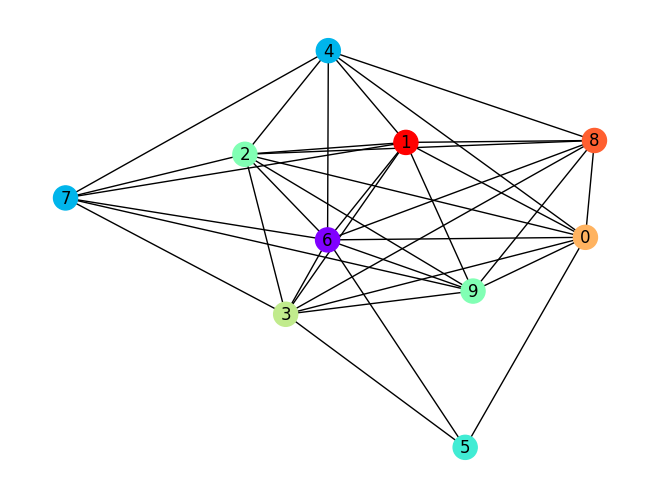

In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

# Step 1: Create a Course Conflict Graph
def create_conflict_graph(num_courses, num_students, max_courses_per_student):
    G = nx.Graph()

    # Add courses as nodes
    for i in range(num_courses):
        G.add_node(i, name=f'Course {i}')

    # Simulate student enrollments
    student_courses = [random.sample(range(num_courses), random.randint(1, max_courses_per_student)) for _ in range(num_students)]

    # Create edges between conflicting courses (taken by the same student)
    for courses in student_courses:
        for i in range(len(courses)):
            for j in range(i + 1, len(courses)):
                G.add_edge(courses[i], courses[j])

    return G

# Step 2: Greedy Graph Coloring for Course Scheduling
def greedy_coloring(G):
    coloring = {}
    for node in sorted(G.nodes(), key=lambda x: len(G[x]), reverse=True):  # Sort by degree
        available_colors = set(range(len(G.nodes())))  # Possible slot options
        used_colors = {coloring[neighbor] for neighbor in G.neighbors(node) if neighbor in coloring}

        for color in available_colors:
            if color not in used_colors:
                coloring[node] = color
                break

    return coloring

# Step 3: Simulated Annealing Optimization
def simulated_annealing(G, coloring, temp=1000, cooling_rate=0.99, iterations=1000):
    current_coloring = coloring.copy()
    best_coloring = coloring.copy()
    best_conflicts = count_conflicts(G, current_coloring)

    for _ in range(iterations):
        node = random.choice(list(G.nodes()))
        old_color = current_coloring[node]
        new_color = random.choice(range(len(G.nodes())))
        current_coloring[node] = new_color

        new_conflicts = count_conflicts(G, current_coloring)
        if new_conflicts < best_conflicts or random.random() < np.exp(-(new_conflicts - best_conflicts) / temp):
            best_coloring = current_coloring.copy()
            best_conflicts = new_conflicts
        else:
            current_coloring[node] = old_color

        temp *= cooling_rate  # Reduce temperature

    return best_coloring

# Helper function to count conflicts
def count_conflicts(G, coloring):
    return sum(1 for u, v in G.edges() if coloring[u] == coloring[v])

# Step 4: Visualization
def visualize_schedule(G, coloring):
    colors = list(coloring.values())
    nx.draw(G, with_labels=True, node_color=colors, cmap=plt.cm.rainbow)
    plt.show()

# Example Execution
num_courses = 10
num_students = 30
max_courses_per_student = 4

graph = create_conflict_graph(num_courses, num_students, max_courses_per_student)
greedy_schedule = greedy_coloring(graph)
optimized_schedule = simulated_annealing(graph, greedy_schedule)

print("Greedy Coloring Schedule:", greedy_schedule)
print("Optimized Schedule (Simulated Annealing):", optimized_schedule)

visualize_schedule(graph, optimized_schedule)